# 04 — Exploratory Data Analysis

Explores return distributions, market statistics, and seasonality using `scripts/analysis.py`, with supporting Matplotlib charts.

In [6]:
import sys
sys.path.append('../scripts')
import pandas as pd
import matplotlib.pyplot as plt

from analysis import summarize_returns, summarize_market, time_based_returns

In [7]:
df = pd.read_csv('../data/processed/xauusd_features.csv', parse_dates=['Date'])
df.shape

(2511, 31)

## Return statistics

In [8]:
return_stats = summarize_returns(df)
pd.Series(return_stats)

mean_return      0.000523
median_return    0.000664
max_return       0.060833
min_return      -0.113662
std_dev          0.010536
variance         0.000111
skewness        -0.699617
kurtosis         8.894842
dtype: float64

## Market statistics

In [9]:
market_stats = summarize_market(df)
pd.Series(market_stats)

highest_close                  5318.399902
lowest_close                   1127.800049
average_daily_range              22.573358
largest_gain_pct                  0.060833
largest_gain_date      2026-02-03 00:00:00
largest_loss_pct                 -0.113662
largest_loss_date      2026-01-30 00:00:00
dtype: object

## Price history

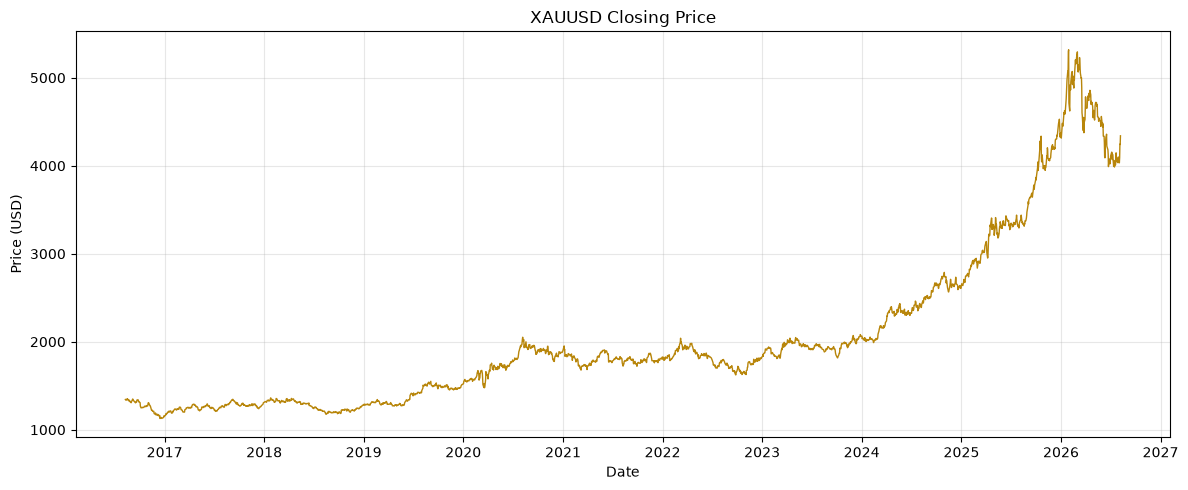

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], color='#b8860b', linewidth=1)
plt.title('XAUUSD Closing Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Daily return distribution

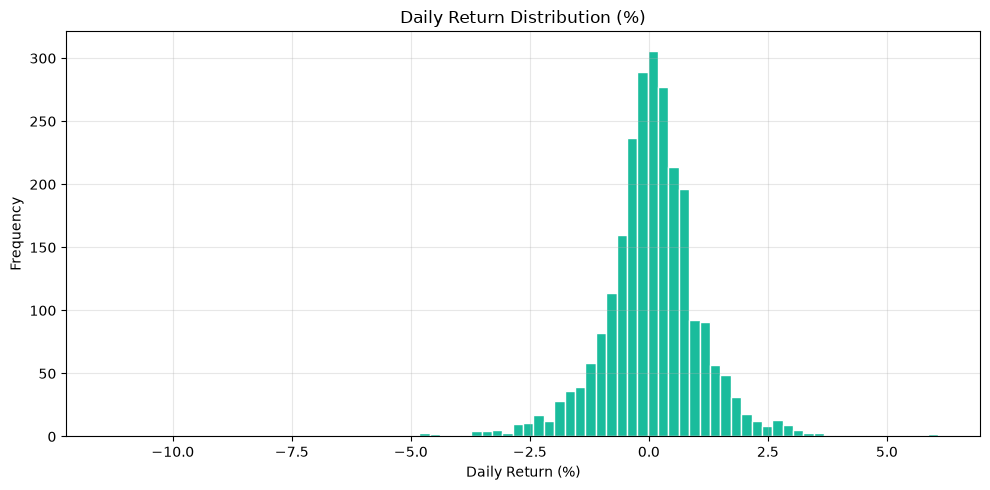

In [11]:
plt.figure(figsize=(10, 5))
plt.hist(df['Daily_Return'].dropna() * 100, bins=80, color='#1abc9c', edgecolor='white')
plt.title('Daily Return Distribution (%)')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Seasonality: average return by year, month, weekday

In [12]:
time_stats = time_based_returns(df)
time_stats['by_year']

Date
2016   -0.001571
2017    0.000529
2018   -0.000065
2019    0.000712
2020    0.000960
2021   -0.000096
2022    0.000030
2023    0.000536
2024    0.001009
2025    0.002061
2026    0.000232
Name: Daily_Return, dtype: float64

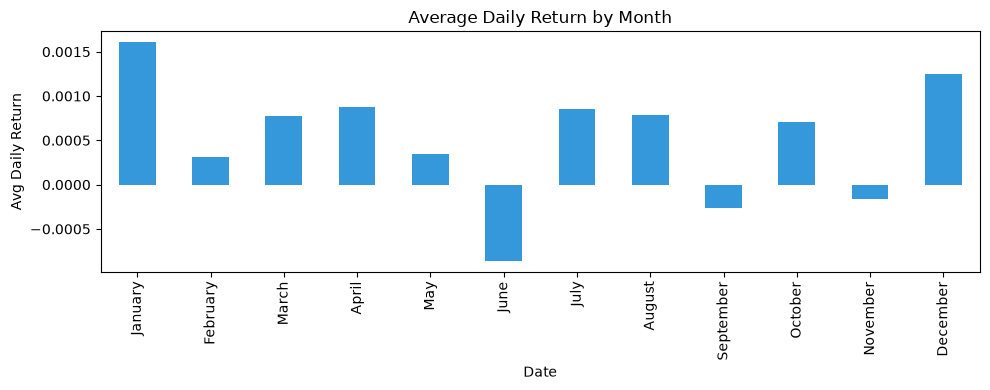

In [13]:
time_stats['by_month'].plot(kind='bar', figsize=(10, 4), color='#3498db', title='Average Daily Return by Month')
plt.ylabel('Avg Daily Return')
plt.tight_layout()
plt.show()

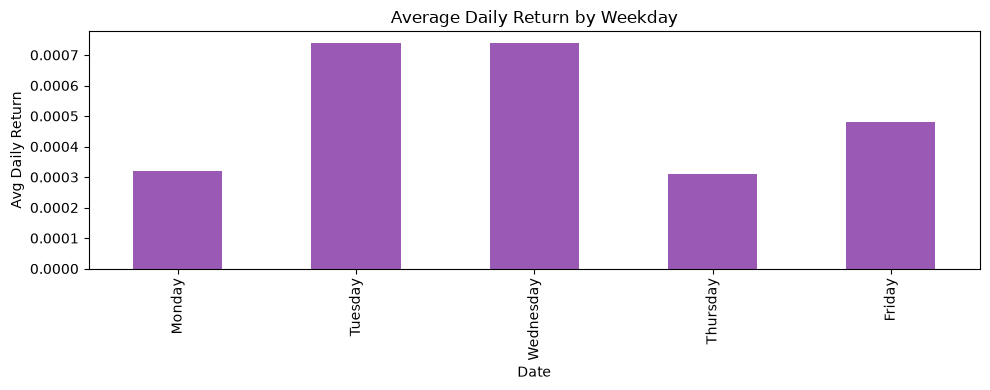

In [14]:
time_stats['by_weekday'].plot(kind='bar', figsize=(10, 4), color='#9b59b6', title='Average Daily Return by Weekday')
plt.ylabel('Avg Daily Return')
plt.tight_layout()
plt.show()

**Next step:** open `05_dashboard.ipynb` for the full interactive Plotly dashboard.